# Convert to Duckdb
## Goal is to make data load faster

In [1]:
import duckdb

con = duckdb.connect()

con.execute("""
    COPY (
        SELECT *
        FROM read_csv_auto('concat_accepted_rejected.csv.gz', ignore_errors=false)
    ) TO 'concat_accepted_rejected.parquet'
    (FORMAT PARQUET);
""")

IOException: IO Error: No files found that match the pattern "concat_accepted_rejected.csv.gz"

LINE 4:         FROM read_csv_auto('concat_accepted_rejected.csv.gz', ignore_errors...
                     ^

In [2]:
con.execute("""
    CREATE VIEW data AS
    SELECT * FROM read_parquet('concat_accepted_rejected.parquet')
""")

con.execute("SELECT COUNT(*) FROM data").fetchdf()

,count_star()
0,4400000


In [1]:
import pandas as pd 

df = pd.read_parquet('concat_accepted_rejected.parquet')
df.head()

ImportError: Unable to find a usable engine; tried using: 'pyarrow', 'fastparquet'.
A suitable version of pyarrow or fastparquet is required for parquet support.
Trying to import the above resulted in these errors:
 - `Import pyarrow` failed. pyarrow is required for parquet support. Use pip or conda to install the pyarrow package.
 - `Import fastparquet` failed. fastparquet is required for parquet support. Use pip or conda to install the fastparquet package.

# Explorer Data Analysis
## Goal is to understand for which variables are important, view summary statistics, and visualize the data

In [4]:
df.describe()

,loan_amnt,int_rate,installment,annual_inc,dti,open_acc,pub_rec,revol_bal,revol_util,total_acc,mort_acc,pub_rec_bankruptcies
count,2.199969e+06,2.199969e+06,2.199969e+06,2.199965e+06,2.198310e+06,2.199941e+06,2.199941e+06,2.199969e+06,2.198226e+06,2.199941e+06,2.151289e+06,2.198639e+06
mean,1.504661e+04,1.309284e+01,4.458131e+02,7.800465e+04,1.882387e+01,1.161284e+01,1.974867e-01,1.665757e+04,5.033527e+01,2.416578e+01,1.555696e+00,1.281939e-01
std,9.189502e+03,4.831740e+00,2.671687e+02,1.137966e+05,1.418629e+01,5.642054e+00,5.671510e-01,2.292382e+04,2.471226e+01,1.199174e+01,1.905249e+00,3.646614e-01
min,5.000000e+02,5.310000e+00,4.930000e+00,0.000000e+00,-1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00
25%,8.000000e+03,9.490000e+00,2.516800e+02,4.600000e+04,1.189000e+01,8.000000e+00,0.000000e+00,5.949000e+03,3.150000e+01,1.500000e+01,0.000000e+00,0.000000e+00
50%,1.290000e+04,1.262000e+01,3.779500e+02,6.500000e+04,1.784000e+01,1.100000e+01,0.000000e+00,1.132300e+04,5.030000e+01,2.200000e+01,1.000000e+00,0.000000e+00
75%,2.000000e+04,1.599000e+01,5.933200e+02,9.300000e+04,2.449000e+01,1.400000e+01,0.000000e+00,2.024300e+04,6.940000e+01,3.100000e+01,3.000000e+00,0.000000e+00
max,4.000000e+04,3.099000e+01,1.719830e+03,1.100000e+08,9.990000e+02,1.010000e+02,6.300000e+01,2.904836e+06,8.923000e+02,1.760000e+02,9.400000e+01,1.200000e+01


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4400000 entries, 0 to 4399999
Data columns (total 28 columns):
 #   Column                Dtype  
---  ------                -----  
 0   loan_amnt             float64
 1   term                  object 
 2   int_rate              float64
 3   installment           float64
 4   grade                 object 
 5   sub_grade             object 
 6   emp_title             object 
 7   emp_length            object 
 8   home_ownership        object 
 9   annual_inc            float64
 10  verification_status   object 
 11  issue_d               object 
 12  loan_status           object 
 13  purpose               object 
 14  title                 object 
 15  zip_code              object 
 16  addr_state            object 
 17  dti                   float64
 18  earliest_cr_line      object 
 19  open_acc              float64
 20  pub_rec               float64
 21  revol_bal             float64
 22  revol_util            float64
 23  total_a

In [6]:
df.isnull().sum()

loan_amnt               2200031
term                    2200031
int_rate                2200031
installment             2200031
grade                   2200031
sub_grade               2200031
emp_title               2362466
emp_length              2342953
home_ownership          2200031
annual_inc              2200035
verification_status     2200031
issue_d                 2200031
loan_status             2200031
purpose                 2200031
title                   2222735
zip_code                2200032
addr_state              2200031
dti                     2201690
earliest_cr_line        2200059
open_acc                2200059
pub_rec                 2200059
revol_bal               2200031
revol_util              2201774
total_acc               2200059
initial_list_status     2200031
application_type        2200031
mort_acc                2248711
pub_rec_bankruptcies    2201361
dtype: int64

In [7]:
df.dropna(inplace=True)
df.info()
df.notnull().sum()

<class 'pandas.core.frame.DataFrame'>
Index: 1970154 entries, 0 to 2199999
Data columns (total 28 columns):
 #   Column                Dtype  
---  ------                -----  
 0   loan_amnt             float64
 1   term                  object 
 2   int_rate              float64
 3   installment           float64
 4   grade                 object 
 5   sub_grade             object 
 6   emp_title             object 
 7   emp_length            object 
 8   home_ownership        object 
 9   annual_inc            float64
 10  verification_status   object 
 11  issue_d               object 
 12  loan_status           object 
 13  purpose               object 
 14  title                 object 
 15  zip_code              object 
 16  addr_state            object 
 17  dti                   float64
 18  earliest_cr_line      object 
 19  open_acc              float64
 20  pub_rec               float64
 21  revol_bal             float64
 22  revol_util            float64
 23  total_acc   

loan_amnt               1970154
term                    1970154
int_rate                1970154
installment             1970154
grade                   1970154
sub_grade               1970154
emp_title               1970154
emp_length              1970154
home_ownership          1970154
annual_inc              1970154
verification_status     1970154
issue_d                 1970154
loan_status             1970154
purpose                 1970154
title                   1970154
zip_code                1970154
addr_state              1970154
dti                     1970154
earliest_cr_line        1970154
open_acc                1970154
pub_rec                 1970154
revol_bal               1970154
revol_util              1970154
total_acc               1970154
initial_list_status     1970154
application_type        1970154
mort_acc                1970154
pub_rec_bankruptcies    1970154
dtype: int64

In [8]:
df[['loan_status']].value_counts()

loan_status       
Fully Paid            938143
Current               772925
Charged Off           229266
Late (31-120 days)     18658
In Grace Period         7445
Late (16-30 days)       3685
Default                   32
Name: count, dtype: int64

In [9]:
remove_statuses = [
    "Current",
    "Late (31-120 days)",
    "In Grace Period",
    "Late (16-30 days)",
    "Default",
]
df = df[~df['loan_status'].isin(remove_statuses)]
df[['loan_status']].value_counts()

loan_status
Fully Paid     938143
Charged Off    229266
Name: count, dtype: int64

In [10]:
import matplotlib.pyplot as plt
import hvplot.pandas

df["loan_status"].value_counts().hvplot.bar(
    title="Loan Status Counts",
    xlabel="Loan Status",
    ylabel="Count",
    width=800,
    height=500
)

:Bars   [loan_status]   (count)

<Axes: >

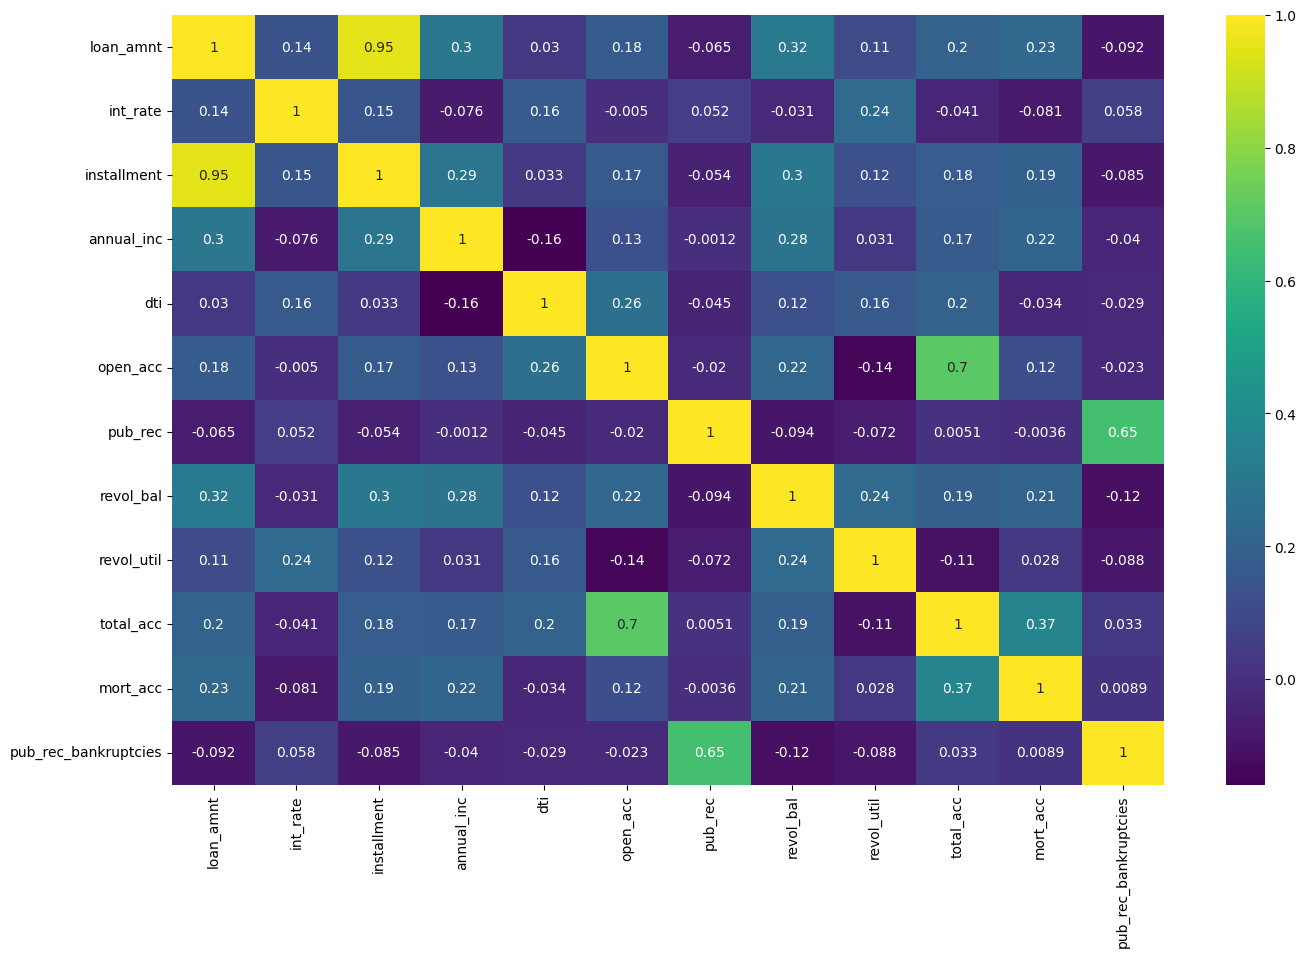

In [11]:
import seaborn as sns

plt.figure(figsize=(16, 10))
corr = df.select_dtypes(include="number").corr()
sns.heatmap(corr, annot=True, cmap="viridis")

## We noticed almost perfect correlation between "loan_amnt" the "installment" feature. We'll explore this features further. Print out their descriptions and perform a scatterplot between them.
### Does this relationship make sense to you?
### Do we think there is duplicate information here?

### loan_amnt & installment
### installment: The monthly payment owed by the borrower if the loan originates.
### loan_amnt: The listed amount of the loan applied for by the borrower. If at some point in time, the credit department reduces the loan amount, then it will be reflected in this value.

In [12]:
installment = df.hvplot.hist(
    y="installment", by="loan_status", subplots=False,
    width=500, height=450, bins=50, alpha=0.4,
    title="Installment by Loan Status",
    xlabel="Installment", ylabel="Counts", legend="top"
)

loan_amnt = df.hvplot.hist(
    y="loan_amnt", by="loan_status", subplots=False,
    width=500, height=450, bins=30, alpha=0.4,
    title="Loan Amount by Loan Status",
    xlabel="Loan Amount", ylabel="Counts", legend="top"
)

installment + loan_amnt

:Layout
   .NdOverlay.I  :NdOverlay   [loan_status]
      :Histogram   [installment]   (Count)
   .NdOverlay.II :NdOverlay   [loan_status]
      :Histogram   [loan_amnt]   (Count)

In [13]:
loan_amnt_box = df.hvplot.box(
    y='loan_amnt', subplots=True, by='loan_status', width=400, height=450, 
    title="Loan Status by Loan Amount ", xlabel='Loan Status', ylabel='Loan Amount'
)

installment_box = df.hvplot.box(
    y='installment', subplots=True, by='loan_status', width=400, height=450, 
    title="Loan Status by Installment", xlabel='Loan Status', ylabel='Installment'
)

loan_amnt_box + installment_box

:Layout
   .BoxWhisker.I  :BoxWhisker   [loan_status]   (loan_amnt)
   .BoxWhisker.II :BoxWhisker   [loan_status]   (installment)

In [14]:
df.groupby(by='loan_status')['loan_amnt'].describe()


,count,mean,std,min,25%,50%,75%,max
loan_status,,,,,,,,
Charged Off,229266.0,15955.667652,8828.547406,1000.0,9600.0,15000.0,21000.0,40000.0
Fully Paid,938143.0,14396.375952,8718.480309,1000.0,8000.0,12000.0,20000.0,40000.0


## grade & sub_grade¶
### grade: LC assigned loan grade
### sub_grade: LC assigned loan subgrade
### Let's explore the Grade and SubGrade columns that LendingClub attributes to the loans.

In [15]:
print(f"GRADE unique: {df.grade.unique()}")
print(f"SUB_GRADE unique: {df.sub_grade.unique()}")

GRADE unique: ['A' 'B' 'C' 'D' 'E' 'F' 'G']
SUB_GRADE unique: ['A3' 'B4' 'B2' 'C4' 'A2' 'B3' 'C2' 'D4' 'E5' 'F3' 'C5' 'C3' 'C1' 'A1'
 'E3' 'B5' 'G3' 'E4' 'A5' 'E2' 'A4' 'D5' 'D3' 'B1' 'D1' 'E1' 'D2' 'G1'
 'F2' 'F4' 'F1' 'G2' 'G4' 'F5' 'G5']


In [16]:
fully_paid = df.loc[df["loan_status"] == "Fully Paid", "grade"].value_counts().hvplot.bar()
charged_off = df.loc[df["loan_status"] == "Charged Off", "grade"].value_counts().hvplot.bar()

grades = (fully_paid * charged_off).opts(
    title="Loan Status by Grade",
    xlabel="Grades",
    ylabel="Count",
    width=900,
    height=550,
    legend_cols=2,
    legend_position="top_right",
)

grades

:Overlay
   .Bars.Count.I  :Bars   [grade]   (count)
   .Bars.Count.II :Bars   [grade]   (count)

In [17]:
fully_paid = df.loc[df['loan_status']=='Fully Paid', 'sub_grade'].value_counts().hvplot.bar() 
charged_off = df.loc[df['loan_status']=='Charged Off', 'sub_grade'].value_counts().hvplot.bar() 

(fully_paid * charged_off).opts(
    title="Loan Status by Grade", xlabel='Grades', ylabel='Count',
    width=900, height=550, legend_cols=2, legend_position='top_right', xrotation=90
)

:Overlay
   .Bars.Count.I  :Bars   [sub_grade]   (count)
   .Bars.Count.II :Bars   [sub_grade]   (count)

C:\Users\User\AppData\Local\Temp\ipykernel_12196\701811099.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  g.set_xticklabels(g.get_xticklabels(), rotation=90);


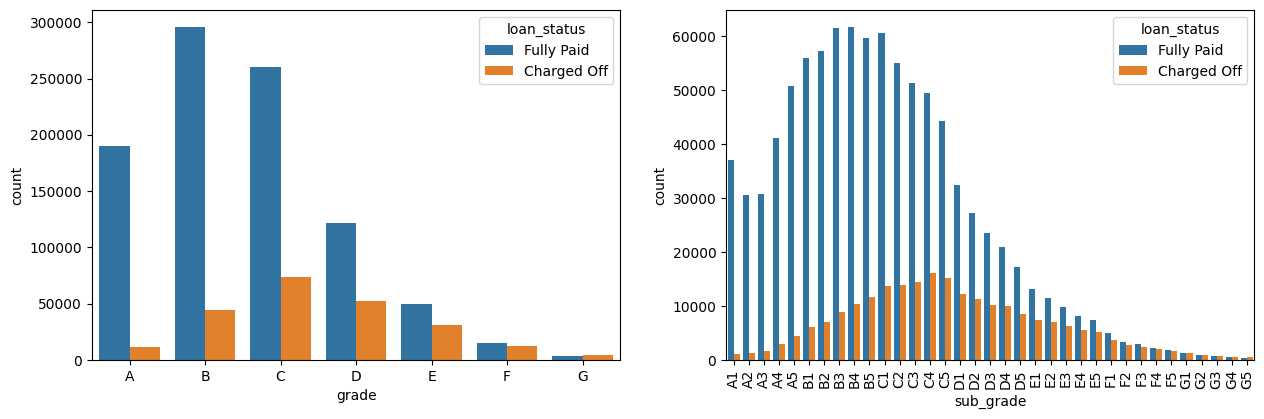

In [18]:
plt.figure(figsize=(15, 10))

plt.subplot(2, 2, 1)
grade = sorted(df.grade.unique().tolist())
sns.countplot(x='grade', data=df, hue='loan_status', order=grade)

plt.subplot(2, 2, 2)
sub_grade = sorted(df.sub_grade.unique().tolist())
g = sns.countplot(x='sub_grade', data=df, hue='loan_status', order=sub_grade)
g.set_xticklabels(g.get_xticklabels(), rotation=90);

### It looks like F and G subgrades don't get paid back that often. Isloate those and recreate the countplot just for those subgrades.

<Axes: xlabel='sub_grade', ylabel='count'>

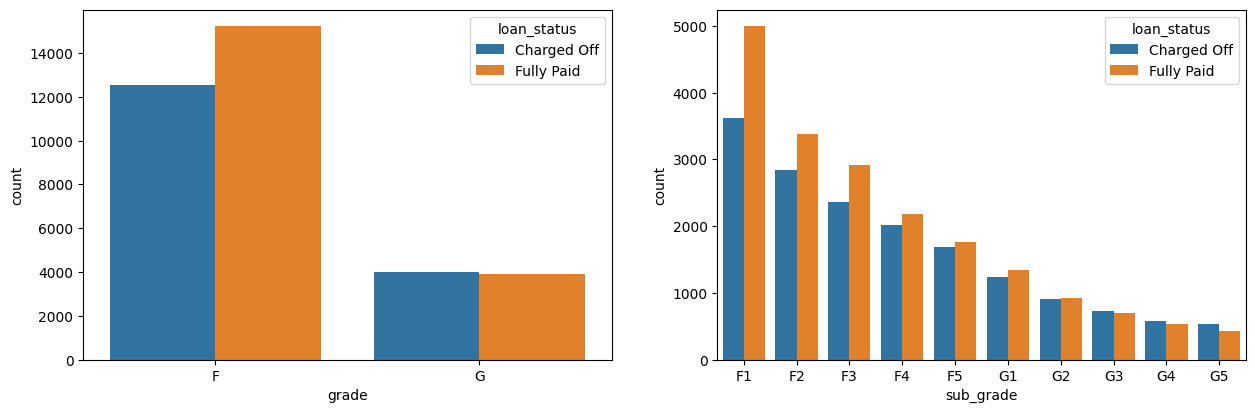

In [19]:
df = df[(df.grade == 'F') | (df.grade == 'G')]

plt.figure(figsize=(15, 10))

plt.subplot(2, 2, 1)
grade = sorted(df.grade.unique().tolist())
sns.countplot(x='grade', data=df, hue='loan_status', order=grade)

plt.subplot(2, 2, 2)
sub_grade = sorted(df.sub_grade.unique().tolist())
sns.countplot(x='sub_grade', data=df, hue='loan_status', order=sub_grade)

## term, home_ownership, verification_status & purpose¶
### term: The number of payments on the loan. Values are in months and can be either 36 or 60.
### home_ownership: The home ownership status provided by the borrower during registration or obtained from the credit report. Our values are: RENT, OWN, MORTGAGE, OTHER
### verification_status: Indicates if income was verified by LC, not verified, or if the income source was verified
### purpose: A category provided by the borrower for the loan request.

In [20]:
df["home_ownership"].value_counts()

home_ownership
MORTGAGE    16220
RENT        15530
OWN          3907
ANY             7
NONE            5
OTHER           2
Name: count, dtype: int64

In [21]:
remove_statuses = [
    "ANY",
    "NONE",
    "OTHER"
]
df = df[~df['home_ownership'].isin(remove_statuses)]
df[['home_ownership']].value_counts()

home_ownership
MORTGAGE          16220
RENT              15530
OWN                3907
Name: count, dtype: int64

In [22]:
fully_paid = df.loc[df['loan_status']=='Fully Paid', 'home_ownership'].value_counts().hvplot.bar() 
charged_off = df.loc[df['loan_status']=='Charged Off', 'home_ownership'].value_counts().hvplot.bar()

home_ownership_count = (fully_paid * charged_off).opts(
    title="Loan Status by Grade", xlabel='Home Ownership', ylabel='Count',
    width=550, height=350, legend_cols=2, legend_position='top_right'
).opts(xrotation=90)

home_ownership = df['home_ownership'].value_counts().hvplot.bar(
    title="Loan Status by Grade", xlabel='Home Ownership', ylabel='Count', 
    width=550, height=350, legend='top'
).opts(xrotation=90)

home_ownership_count + home_ownership

:Layout
   .Overlay.Count :Overlay
      .Bars.Count.I  :Bars   [home_ownership]   (count)
      .Bars.Count.II :Bars   [home_ownership]   (count)
   .Bars.Count    :Bars   [home_ownership]   (count)

C:\Users\User\AppData\Local\Temp\ipykernel_12196\4114434251.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  g.set_xticklabels(g.get_xticklabels(), rotation=90);


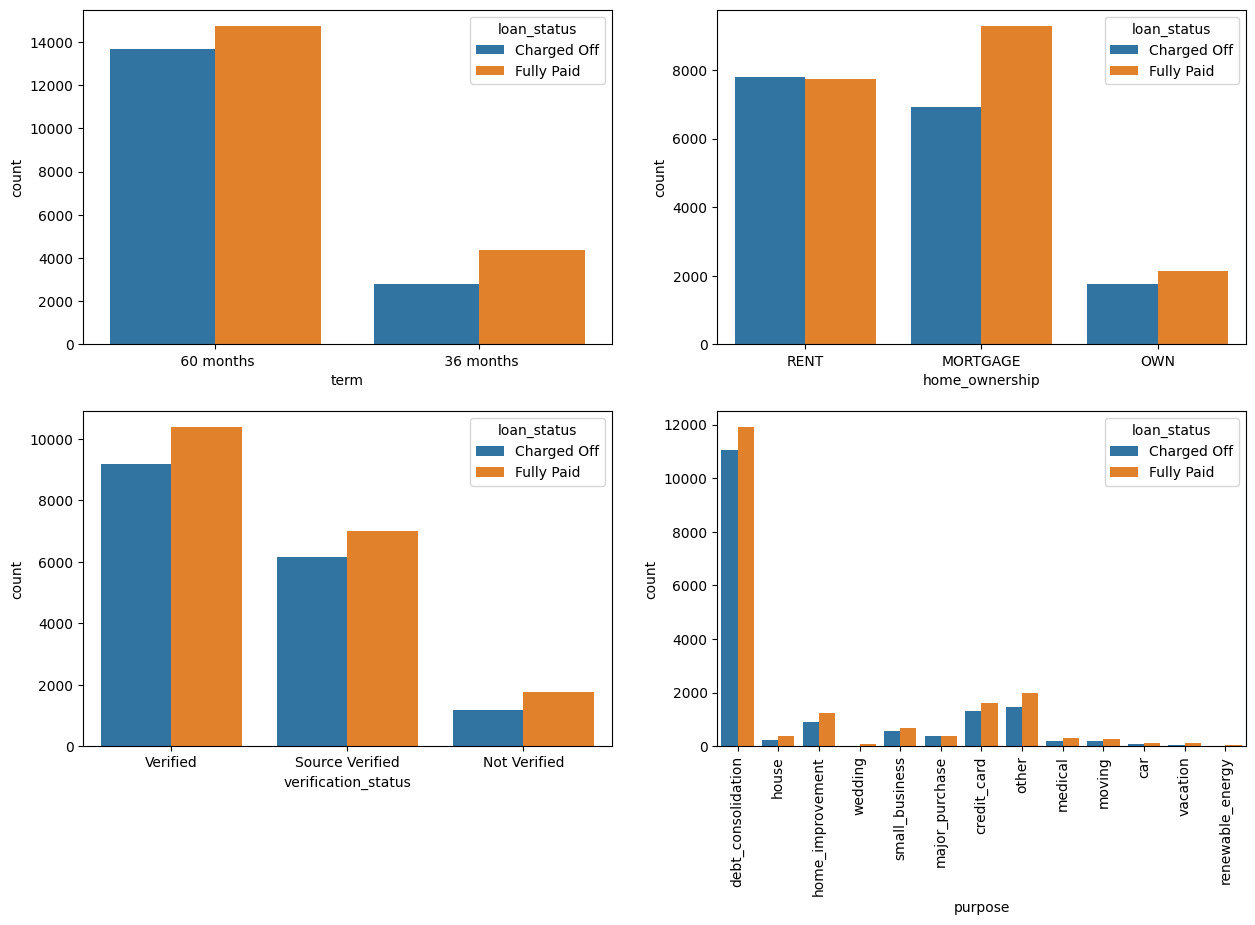

In [23]:
plt.figure(figsize=(15, 20))

plt.subplot(4, 2, 1)
sns.countplot(x='term', data=df, hue='loan_status')

plt.subplot(4, 2, 2)
sns.countplot(x='home_ownership', data=df, hue='loan_status')

plt.subplot(4, 2, 3)
sns.countplot(x='verification_status', data=df, hue='loan_status')

plt.subplot(4, 2, 4)
g = sns.countplot(x='purpose', data=df, hue='loan_status')
g.set_xticklabels(g.get_xticklabels(), rotation=90);

## int_rate & annual_inc
### int_rate: Interest Rate on the loan
### annual_inc: The self-reported annual income provided by the borrower during registration

In [24]:
int_rate = df.hvplot.hist(
    y='int_rate', by='loan_status', alpha=0.3, width=350, height=400,
    title="Loan Status by Interest Rate", xlabel='Interest Rate', ylabel='Loans Counts', 
    legend='top'
)

annual_inc = df.hvplot.hist(
    y='annual_inc', by='loan_status', bins=50, alpha=0.3, width=550, height=400,
    title="Loan Status by Annual Income", xlabel='Annual Income', ylabel='Loans Counts', 
    legend='top'
).opts(xrotation=45)

int_rate + annual_inc

:Layout
   .NdOverlay.I  :NdOverlay   [loan_status]
      :Histogram   [int_rate]   (Count)
   .NdOverlay.II :NdOverlay   [loan_status]
      :Histogram   [annual_inc]   (Count)

In [25]:
df[df.annual_inc <= 250000].hvplot.hist(
    y='annual_inc', by='loan_status', bins=50, alpha=0.3, width=900, height=500,
    title="Loan Status by Annual Income (<= 250000/Year)", 
    xlabel='Annual Income', ylabel='Loans Counts', legend='top'
).opts(xrotation=45)

:NdOverlay   [loan_status]
   :Histogram   [annual_inc]   (Count)

In [26]:
print((df[df.annual_inc >= 250000].shape[0] / df.shape[0]) * 100)
print((df[df.annual_inc >= 1000000].shape[0] / df.shape[0]) * 100)

0.9675519533331463
0.005608996830916791


In [27]:
df.loc[df.annual_inc >= 250000, 'loan_status'].value_counts()

loan_status
Fully Paid     241
Charged Off    104
Name: count, dtype: int64

It seems that loans with high intersest rate are more likely to be unpaid. 
Only 75 (less then) borrowers have an annual income more than 1 million

## emp_title & emp_length
### emp_title: The job title supplied by the Borrower when applying for the loan.
### emp_length: Employment length in years. Possible values are between 0 and 10 where 0 means less than one year and 10 means ten or more years.

In [28]:
df['emp_title'].value_counts()[:20]

emp_title
Manager               598
Teacher               482
Supervisor            276
Owner                 261
Driver                239
Registered Nurse      227
RN                    203
Sales                 194
manager               162
General Manager       149
Office Manager        148
Project Manager       143
driver                136
Engineer              123
Director              109
owner                 108
supervisor            103
Operations Manager     92
teacher                88
Nurse                  87
Name: count, dtype: int64

In [29]:
print(df.emp_title.nunique())

19588


C:\Users\User\AppData\Local\Temp\ipykernel_12196\817212938.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  g.set_xticklabels(g.get_xticklabels(), rotation=90);


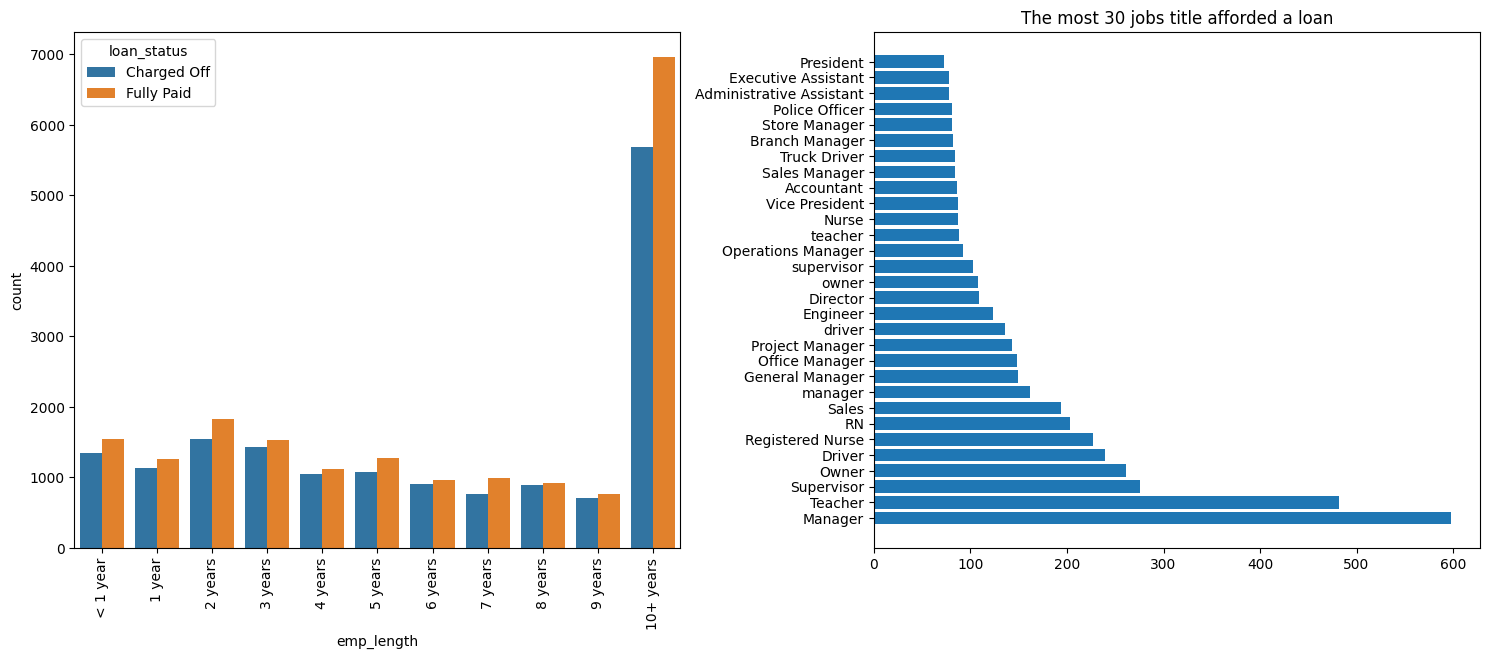

In [30]:
plt.figure(figsize=(15, 12))

plt.subplot(2, 2, 1)
order = ['< 1 year', '1 year', '2 years', '3 years', '4 years', '5 years', 
          '6 years', '7 years', '8 years', '9 years', '10+ years',]
g = sns.countplot(x='emp_length', data=df, hue='loan_status', order=order)
g.set_xticklabels(g.get_xticklabels(), rotation=90);

plt.subplot(2, 2, 2)
plt.barh(df.emp_title.value_counts()[:30].index, df.emp_title.value_counts()[:30])
plt.title("The most 30 jobs title afforded a loan")
plt.tight_layout()

## issue_d, earliest_cr_line
### issue_d: The month which the loan was funded
### earliest_cr_line: The month the borrower's earliest reported credit line was opened

In [31]:
df['earliest_cr_line'].value_counts()

earliest_cr_line
Sep-2003    287
Sep-2004    285
Aug-2001    263
Oct-2002    261
Aug-2004    258
           ... 
Jan-1962      1
Jul-1975      1
Feb-1973      1
Apr-2014      1
Feb-1969      1
Name: count, Length: 558, dtype: int64

In [32]:
df["issue_d"] = pd.to_datetime(df["issue_d"], format="%b-%Y", errors="coerce")
df["earliest_cr_line"] = pd.to_datetime(df["earliest_cr_line"], format="%b-%Y", errors="coerce")

In [33]:
fully_paid = df.loc[df['loan_status']=='Fully Paid', 'issue_d'].hvplot.hist(bins=35) 
charged_off = df.loc[df['loan_status']=='Charged Off', 'issue_d'].hvplot.hist(bins=35)

# fully_paid * charged_off
loan_issue_date = (fully_paid * charged_off).opts(
    title="Loan Status by Loan Issue Date", xlabel='Loan Issue Date', ylabel='Count',
    width=550, height=350, legend_cols=2, legend_position='top_right'
).opts(xrotation=45)

fully_paid = df.loc[df['loan_status']=='Fully Paid', 'earliest_cr_line'].hvplot.hist(bins=35) 
charged_off = df.loc[df['loan_status']=='Charged Off', 'earliest_cr_line'].hvplot.hist(bins=35)

earliest_cr_line = (fully_paid * charged_off).opts(
    title="Loan Status by earliest_cr_line", xlabel='earliest_cr_line', ylabel='Count',
    width=550, height=350, legend_cols=2, legend_position='top_right'
).opts(xrotation=45)

loan_issue_date + earliest_cr_line

:Layout
   .Overlay.I  :Overlay
      .Histogram.I  :Histogram   [issue_d]   (Count)
      .Histogram.II :Histogram   [issue_d]   (Count)
   .Overlay.II :Overlay
      .Histogram.I  :Histogram   [earliest_cr_line]   (Count)
      .Histogram.II :Histogram   [earliest_cr_line]   (Count)

## title
### title: The loan title provided by the borrower

In [34]:

df.title.value_counts()[:10]

title
Debt consolidation         19965
Other                       2850
Credit card refinancing     2393
Home improvement            1930
Business                    1131
Major purchase               709
Home buying                  603
Debt Consolidation           536
Medical expenses             429
Moving and relocation        406
Name: count, dtype: int64

## pub_rec, initial_list_status, application_type, mort_acc, & pub_rec_bankruptcies
### pub_rec: Number of derogatory public records
### initial_list_status: The initial listing status of the loan. Possible values are – W, F
### application_type: Indicates whether the loan is an individual application or a joint application with two co-borrowers
### mort_acc: Number of mortgage accounts
### pub_rec_bankruptcies: Number of public record bankruptcies

In [35]:
xlabel = "The initial listing status of the loan"
title = "Loan Status by The initial listing status of the loan"

fully_paid = df.loc[df['loan_status']=='Fully Paid', 'initial_list_status'].value_counts().hvplot.bar() 
charged_off = df.loc[df['loan_status']=='Charged Off', 'initial_list_status'].value_counts().hvplot.bar()

(fully_paid * charged_off).opts(
    title=title, xlabel=xlabel, ylabel='Count',
    width=800, height=400, legend_cols=2, legend_position='top_right')

:Overlay
   .Bars.Count.I  :Bars   [initial_list_status]   (count)
   .Bars.Count.II :Bars   [initial_list_status]   (count)

In [36]:
fully_paid = df.loc[df['loan_status']=='Fully Paid', 'application_type'].value_counts().hvplot.bar() 
charged_off = df.loc[df['loan_status']=='Charged Off', 'application_type'].value_counts().hvplot.bar()

(fully_paid * charged_off).opts(
    title="Loan Status by Application Type", xlabel="Application Type", ylabel='Count',
    width=800, height=400, legend_cols=2, legend_position='top_right'
)

:Overlay
   .Bars.Count.I  :Bars   [application_type]   (count)
   .Bars.Count.II :Bars   [application_type]   (count)

In [37]:
xlabel = "Number of public record bankruptcies"
title = "Loan Status by The Number of public record bankruptcies"

fully_paid = df.loc[df['loan_status']=='Fully Paid', 'pub_rec_bankruptcies'].value_counts().hvplot.bar() 
charged_off = df.loc[df['loan_status']=='Charged Off', 'pub_rec_bankruptcies'].value_counts().hvplot.bar()

(fully_paid * charged_off).opts(
    title=title, xlabel=xlabel, ylabel='Count',
    width=800, height=400, legend_cols=2, legend_position='top_right'
)

:Overlay
   .Bars.Count.I  :Bars   [pub_rec_bankruptcies]   (count)
   .Bars.Count.II :Bars   [pub_rec_bankruptcies]   (count)

## How numeric features correlate with the target variable?

In [38]:
if df["loan_status"].dtype == "object":
    df["loan_status"] = df["loan_status"].replace({"Fully Paid": 1, "Charged Off": 0})

corr = (
    df.select_dtypes(include="number")
      .corr()["loan_status"]
      .drop("loan_status")
      .dropna()
      .sort_values()
)

corr.hvplot.barh(
    width=700,
    height=450,
    title="Correlation between Loan Status and Numeric Features",
    xlabel="Correlation",
    ylabel="Numeric Features",
)

C:\Users\User\AppData\Local\Temp\ipykernel_12196\4259953758.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["loan_status"] = df["loan_status"].replace({"Fully Paid": 1, "Charged Off": 0})


:Bars   [index]   (loan_status)

### Features related to the applicant (demographic variables such as occupation, employment details etc.),
### Features related to loan characteristics (amount of loan, interest rate, purpose of loan etc.)

# Outliers Detection and Removing

## Data Preprocessing
### Remove or fill any missing data.
### Remove unnecessary or repetitive features.
### Convert categorical string features to dummy variables.

In [39]:
print(f"The Length of the data: {df.shape}")

The Length of the data: (35657, 28)


In [40]:
# Missing values
for column in df.columns:
    if df[column].isna().sum() != 0:
        missing = df[column].isna().sum()
        portion = (missing / df.shape[0]) * 100
        print(f"'{column}': number of missing values '{missing}' ==> '{portion:.3f}%'")

## emp_title

In [41]:
df.emp_title.nunique()

19588

Realistically there are too many unique job titles to try to convert this to a dummy variable feature. Let's remove that emp_title column.    


In [42]:
df.drop('emp_title', axis=1, inplace=True)

## emp_length

In [43]:
df.emp_length.unique()

array(['10+ years', '7 years', '9 years', '6 years', '< 1 year',
       '3 years', '4 years', '5 years', '2 years', '1 year', '8 years'],
      dtype=object)

In [44]:
for year in df.emp_length.unique():
    print(f"{year} years in this position:")
    print(f"{df[df.emp_length == year].loan_status.value_counts(normalize=True)}")
    print('==========================================')

10+ years years in this position:
loan_status
1    0.550612
0    0.449388
Name: proportion, dtype: float64
7 years years in this position:
loan_status
1    0.563073
0    0.436927
Name: proportion, dtype: float64
9 years years in this position:
loan_status
1    0.52
0    0.48
Name: proportion, dtype: float64
6 years years in this position:
loan_status
1    0.51826
0    0.48174
Name: proportion, dtype: float64
< 1 year years in this position:
loan_status
1    0.535764
0    0.464236
Name: proportion, dtype: float64
3 years years in this position:
loan_status
1    0.518456
0    0.481544
Name: proportion, dtype: float64
4 years years in this position:
loan_status
1    0.516129
0    0.483871
Name: proportion, dtype: float64
5 years years in this position:
loan_status
1    0.54023
0    0.45977
Name: proportion, dtype: float64
2 years years in this position:
loan_status
1    0.542968
0    0.457032
Name: proportion, dtype: float64
1 year years in this position:
loan_status
1    0.525261
0    0.

Charge off rates are extremely similar across all employment lengths. So we are going to drop the emp_length column.

In [45]:
df.drop('emp_length', axis=1, inplace=True)

## title

In [46]:
df.title.value_counts().head()

title
Debt consolidation         19965
Other                       2850
Credit card refinancing     2393
Home improvement            1930
Business                    1131
Name: count, dtype: int64

In [47]:
df.purpose.value_counts().head()

purpose
debt_consolidation    22951
other                  3457
credit_card            2961
home_improvement       2143
small_business         1256
Name: count, dtype: int64

The title column is simply a string subcategory/description of the purpose column. So we are going to drop the title column.



In [48]:
df.drop('title', axis=1, inplace=True)

## mort_acc
### number of mortage account on the borrow of credit account

In [49]:
df.mort_acc.value_counts()[:10]

C:\Users\User\AppData\Local\Temp\ipykernel_12196\1456279687.py:1: FutureWarning: The behavior of obj[i:j] with a float-dtype index is deprecated. In a future version, this will be treated as positional instead of label-based. For label-based slicing, use obj.loc[i:j] instead
  df.mort_acc.value_counts()[:10]


mort_acc
0.0     15874
1.0      6518
2.0      4843
3.0      3235
4.0      2210
5.0      1308
6.0       750
7.0       432
8.0       229
9.0       108
10.0       64
Name: count, dtype: int64

In [50]:
df["term"] = df["term"].str.strip().str.replace("months", "", regex=False).astype(int)
df.corr(numeric_only=True)["mort_acc"].drop("mort_acc").sort_values().hvplot.barh()

:Bars   [index]   (mort_acc)

Looks like the total_acc feature correlates with the mort_acc 

In [51]:
total_acc_avg = df.groupby("total_acc")["mort_acc"].mean()

In [52]:
import numpy as np
def fill_mort_acc(total_acc, mort_acc):
    if np.isnan(mort_acc):
        return total_acc_avg[total_acc].round()
    else:
        return mort_acc

df['mort_acc'] = df.apply(lambda x: fill_mort_acc(x['total_acc'], x['mort_acc']), axis=1)


## revol_util & pub_rec_bankruptcies

In [53]:
for column in df.columns:
    if df[column].isna().sum() != 0:
        missing = df[column].isna().sum()
        portion = (missing / df.shape[0]) * 100
        print(f"'{column}': number of missing values '{missing}' ==> '{portion:.3f}%'")

In [54]:
df.dropna(inplace=True)
df.shape

(35657, 25)

## Categorical Variables and Dummy Variables

In [55]:
print([column for column in df.columns if df[column].dtype == object])

['grade', 'sub_grade', 'home_ownership', 'verification_status', 'purpose', 'zip_code', 'addr_state', 'initial_list_status', 'application_type']


In [56]:
df.term.unique()

array([60, 36])

grade & sub_grade are feature so drop it

In [57]:
df.drop('grade', axis=1, inplace=True)

In [58]:
dummies = ['sub_grade', 'verification_status', 'purpose', 'initial_list_status', 
           'application_type', 'home_ownership']
dummies_existing = [c for c in dummies if c in df.columns]
if dummies_existing:
    df = pd.get_dummies(df, columns=dummies_existing, drop_first=True)
df.head()

,loan_amnt,term,int_rate,installment,annual_inc,issue_d,loan_status,zip_code,addr_state,dti,...,purpose_moving,purpose_other,purpose_renewable_energy,purpose_small_business,purpose_vacation,purpose_wedding,initial_list_status_w,application_type_Joint App,home_ownership_OWN,home_ownership_RENT
23,12375.0,60,24.50,359.61,45000.0,2013-10-01,0,974xx,OR,15.87,...,False,False,False,False,False,False,True,False,False,True
66,12225.0,60,28.34,383.15,50000.0,2016-04-01,0,700xx,LA,8.45,...,False,False,False,False,False,False,True,False,False,False
312,35000.0,60,25.80,1043.78,109800.0,2013-07-01,1,221xx,VA,23.02,...,False,False,False,False,False,False,False,False,False,True
342,18750.0,60,24.08,540.28,60000.0,2014-06-01,1,553xx,MN,13.38,...,False,False,False,False,False,False,False,False,False,False
348,35000.0,60,24.89,1025.05,120000.0,2013-09-01,1,769xx,TX,12.40,...,False,False,False,False,False,False,False,False,True,False


## addr_state (address)
### feature engineer a zip code column from the address in the data set. Create a column called 'zip_code' that extracts the zip code from the address column.

In [59]:
df.addr_state.head()

23     OR
66     LA
312    VA
342    MN
348    TX
Name: addr_state, dtype: object

In [60]:
df['zip_code'] = df.addr_state.apply(lambda x: x[-5:])
df.zip_code.value_counts()

zip_code
CA    5068
NY    3041
TX    2896
FL    2459
IL    1290
NJ    1263
GA    1252
PA    1209
OH    1145
VA    1111
NC    1089
MD     909
MI     908
WA     794
CO     782
MA     763
AZ     748
MN     646
IN     605
TN     584
MO     535
NV     516
AL     510
CT     483
SC     458
WI     438
LA     434
OR     373
KY     336
OK     334
UT     283
AR     275
KS     269
HI     247
MS     196
NM     193
RI     155
NH     149
WV     112
DE     105
NE      95
AK      93
MT      87
DC      77
WY      74
SD      73
VT      55
ME      48
ID      48
ND      44
Name: count, dtype: int64

In [61]:
df = pd.get_dummies(df, columns=['zip_code'], drop_first=True)


In [62]:
df.drop('addr_state', axis=1, inplace=True)

## issue_d
### This would be data leakage, we wouldn't know beforehand whether or not a loan would be issued when using our model, so in theory we wouldn't have an issue_date, drop this feature.

In [63]:
df.drop('issue_d', axis=1, inplace=True)

## earliest_cr_line
### This appears to be a historical time stamp feature. Extract the year from this feature using a .apply() function, then convert it to a numeric feature.

In [64]:
df['earliest_cr_line'] = df.earliest_cr_line.dt.year

In [65]:
df.earliest_cr_line.nunique()

55

In [66]:
df.earliest_cr_line.value_counts()

earliest_cr_line
2004    2616
2003    2530
2001    2456
2002    2408
2005    2353
2000    2222
2006    2080
1999    1958
2007    1615
1998    1608
1997    1455
1996    1299
1995    1249
1994    1043
2008     960
1993     839
2009     716
2010     680
2011     611
1992     546
1991     507
1990     503
1989     474
2012     443
1988     384
1987     362
1986     264
1985     244
1984     211
2013     192
1983     138
1982     105
1978      78
1981      75
1977      60
1980      58
1979      57
1976      49
2014      43
1974      28
1975      27
1972      21
1973      19
1971      15
1970      12
1966       8
1967       8
1969       8
1968       7
2015       5
1964       3
1963       2
1965       1
1960       1
1962       1
Name: count, dtype: int64

## Check for duplicates columns & features

In [67]:
print(f"Data shape: {df.shape}")

# Remove duplicate Features
df = df.T.drop_duplicates()
df = df.T

# Remove Duplicate Rows
df.drop_duplicates(inplace=True)

print(f"Data shape: {df.shape}")

Data shape: (35657, 91)
Data shape: (35657, 91)


# Train_Test_Split

In [68]:
w_p = df.loan_status.value_counts()[0] / df.shape[0]
w_n = df.loan_status.value_counts()[1] / df.shape[0]

print(f"Weight of positive values {w_p}")
print(f"Weight of negative values {w_n}")

Weight of positive values 0.4630226883921811
Weight of negative values 0.5369773116078189


In [69]:
from sklearn.model_selection import train_test_split

train, test = train_test_split(df, test_size=0.25, random_state=168)

print(train.shape)
print(test.shape)

(26742, 91)
(8915, 91)


# Removing Outliers

In [70]:
print(train[train['dti'] <= 50].shape)
print(train.shape)

(26664, 91)
(26742, 91)


In [71]:
print(train.shape)
train = train[train['annual_inc'] <= 250000]
train = train[train['dti'] <= 50]
train = train[train['open_acc'] <= 40]
train = train[train['total_acc'] <= 80]
train = train[train['revol_util'] <= 120]
train = train[train['revol_bal'] <= 250000]
print(train.shape)

(26742, 91)
(26375, 91)


## Normalizing the data

In [72]:
X_train, y_train = train.drop('loan_status', axis=1), train.loan_status
X_test, y_test = test.drop('loan_status', axis=1), test.loan_status

In [73]:
X_train.dtypes

loan_amnt      object
term           object
int_rate       object
installment    object
annual_inc     object
                ...  
zip_code_VT    object
zip_code_WA    object
zip_code_WI    object
zip_code_WV    object
zip_code_WY    object
Length: 90, dtype: object

## Scaler

In [74]:

from sklearn.preprocessing import MinMaxScaler

def scale(x):
    mean = np.mean(x, axis=0)
    std = np.std(x, axis=0)
    return (x - mean) / std, mean, std

x_train, mean, std = scale(X_train)
x_test = (X_test - mean) / std
x_train


,loan_amnt,term,int_rate,installment,annual_inc,dti,earliest_cr_line,open_acc,pub_rec,revol_bal,...,zip_code_SD,zip_code_TN,zip_code_TX,zip_code_UT,zip_code_VA,zip_code_VT,zip_code_WA,zip_code_WI,zip_code_WV,zip_code_WY
1044688,-0.831217,0.505563,-0.975938,-0.956102,-1.037957,1.840923,0.555951,0.15706,-0.364829,-0.006596,...,-0.048147,-0.12889,-0.298364,-0.090444,-0.179581,-0.040878,-0.147553,-0.111173,-0.056186,-0.044872
1843436,-0.393217,0.505563,-0.059681,-0.475405,-0.175666,-0.279545,0.703455,-1.085533,-0.364829,-0.66417,...,-0.048147,-0.12889,3.351612,-0.090444,-0.179581,-0.040878,-0.147553,-0.111173,-0.056186,-0.044872
855301,0.592283,-1.977994,-1.043531,1.266537,0.491914,1.126577,-0.181568,-0.197967,-0.364829,0.716829,...,-0.048147,-0.12889,-0.298364,-0.090444,-0.179581,-0.040878,-0.147553,-0.111173,-0.056186,-0.044872
1762230,1.169896,0.505563,1.600097,1.309793,-0.326428,0.607463,-1.214095,-0.020454,-0.364829,0.837998,...,-0.048147,-0.12889,-0.298364,-0.090444,-0.179581,-0.040878,-0.147553,-0.111173,-0.056186,-0.044872
2004255,-0.048292,0.505563,0.124322,-0.124758,-0.342561,0.218128,0.850959,-1.085533,-0.364829,-0.553531,...,-0.048147,-0.12889,-0.298364,-0.090444,-0.179581,-0.040878,-0.147553,-0.111173,-0.056186,-0.044872
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
623565,-1.926217,-1.977994,1.847937,-1.853674,-0.342561,-0.993891,0.998463,0.15706,-0.364829,-0.795065,...,-0.048147,-0.12889,-0.298364,-0.090444,-0.179581,-0.040878,-0.147553,-0.111173,-0.056186,-0.044872
941772,-0.516405,0.505563,-0.059681,-0.593632,-0.787615,-0.066256,-1.066591,-1.085533,-0.364829,-0.6047,...,-0.048147,-0.12889,-0.298364,-0.090444,-0.179581,-0.040878,-0.147553,-0.111173,-0.056186,-0.044872
654713,-1.09128,-1.977994,1.111927,-0.734726,-0.676351,0.802695,0.703455,-0.552993,-0.364829,-0.766198,...,-0.048147,-0.12889,-0.298364,-0.090444,-0.179581,-0.040878,-0.147553,-0.111173,-0.056186,-0.044872
722301,0.378758,0.505563,0.604982,0.351302,1.187309,1.169461,-0.919087,1.044626,-0.364829,1.016779,...,-0.048147,-0.12889,3.351612,-0.090444,-0.179581,-0.040878,-0.147553,-0.111173,-0.056186,-0.044872


# Model Building

In [75]:
X_train = np.array(X_train).astype(np.float32)
X_test = np.array(X_test).astype(np.float32)
y_train = np.array(y_train).astype(np.float32)
y_test = np.array(y_test).astype(np.float32)

## Artificial Neural Network

In [76]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_auc_score
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [77]:
def print_score(true, pred, train=True):
    if train:
        clf_report = pd.DataFrame(classification_report(true, pred, output_dict=True))
        print("Train Result:\n================================================")
        print(f"Accuracy Score: {accuracy_score(true, pred) * 100:.2f}%")
        print("_______________________________________________")
        print(f"CLASSIFICATION REPORT:\n{clf_report}")
        print("_______________________________________________")
        print(f"Confusion Matrix: \n {confusion_matrix(true, pred)}\n")
        
    elif train==False:
        clf_report = pd.DataFrame(classification_report(true, pred, output_dict=True))
        print("Test Result:\n================================================")        
        print(f"Accuracy Score: {accuracy_score(true, pred) * 100:.2f}%")
        print("_______________________________________________")
        print(f"CLASSIFICATION REPORT:\n{clf_report}")
        print("_______________________________________________")
        print(f"Confusion Matrix: \n {confusion_matrix(true, pred)}\n")

In [78]:
X_train = np.array(X_train).astype(np.float32)
X_test = np.array(X_test).astype(np.float32)
y_train = np.array(y_train).astype(np.float32)
y_test = np.array(y_test).astype(np.float32)

In [79]:
import tensorflow as tf
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.metrics import AUC


def evaluate_nn(true, pred, train=True):
    if train:
        clf_report = pd.DataFrame(classification_report(true, pred, output_dict=True))
        print("Train Result:\n================================================")
        print(f"Accuracy Score: {accuracy_score(true, pred) * 100:.2f}%")
        print("_______________________________________________")
        print(f"CLASSIFICATION REPORT:\n{clf_report}")
        print("_______________________________________________")
        print(f"Confusion Matrix: \n {confusion_matrix(true, pred)}\n")
        
    elif train==False:
        clf_report = pd.DataFrame(classification_report(true, pred, output_dict=True))
        print("Test Result:\n================================================")        
        print(f"Accuracy Score: {accuracy_score(true, pred) * 100:.2f}%")
        print("_______________________________________________")
        print(f"CLASSIFICATION REPORT:\n{clf_report}")
        print("_______________________________________________")
        print(f"Confusion Matrix: \n {confusion_matrix(true, pred)}\n")
        
def plot_learning_evolution(r):
    plt.figure(figsize=(12, 8))
    
    plt.subplot(2, 2, 1)
    plt.plot(r.history['loss'], label='Loss')
    plt.plot(r.history['val_loss'], label='val_Loss')
    plt.title('Loss evolution during trainig')
    plt.legend()

    plt.subplot(2, 2, 2)
    plt.plot(r.history['AUC'], label='AUC')
    plt.plot(r.history['val_AUC'], label='val_AUC')
    plt.title('AUC score evolution during trainig')
    plt.legend();

def nn_model(num_columns, num_labels, hidden_units, dropout_rates, learning_rate):
    inp = tf.keras.layers.Input(shape=(num_columns, ))
    x = BatchNormalization()(inp)
    x = Dropout(dropout_rates[0])(x)
    for i in range(len(hidden_units)):
        x = Dense(hidden_units[i], activation='relu')(x)
        x = BatchNormalization()(x)
        x = Dropout(dropout_rates[i + 1])(x)
    x = Dense(num_labels, activation='sigmoid')(x)
  
    model = Model(inputs=inp, outputs=x)
    model.compile(optimizer=Adam(learning_rate), loss='binary_crossentropy', metrics=[AUC(name='AUC')])
    return model

In [80]:
num_columns = X_train.shape[1]
num_labels = 1
hidden_units = [150, 150, 150]
dropout_rates = [0.1, 0, 0.1, 0]
learning_rate = 1e-3


model = nn_model(
    num_columns=num_columns, 
    num_labels=num_labels,
    hidden_units=hidden_units,
    dropout_rates=dropout_rates,
    learning_rate=learning_rate
)
r = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=20,
    batch_size=32
)

Epoch 1/20
825/825 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - AUC: 0.5526 - loss: 0.7218 - val_AUC: 0.5631 - val_loss: 0.7036
Epoch 2/20
825/825 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - AUC: 0.5989 - loss: 0.6788 - val_AUC: 0.5879 - val_loss: 0.6900
Epoch 3/20
825/825 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - AUC: 0.6089 - loss: 0.6732 - val_AUC: 0.5931 - val_loss: 0.6823
Epoch 4/20
825/825 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - AUC: 0.6186 - loss: 0.6694 - val_AUC: 0.5985 - val_loss: 0.6866
Epoch 5/20
825/825 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - AUC: 0.6290 - loss: 0.6653 - val_AUC: 0.6042 - val_loss: 0.6841
Epoch 6/20
825/825 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - AUC: 0.6334 - loss: 0.6631 - val_AUC: 0.5980 - val_loss: 0.6854
Epoch 7/20
825/825 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - AUC: 0.6342 - loss: 0.6624 - val_AUC: 0.6006 - val_loss: 0.6958
Epoch 8/20
825/825 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - AUC: 0.6400 - loss: 0.6601 - val_AUC: 0.5902 - val_loss: 0.6834
Epoch 9/20
825/825 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - AU

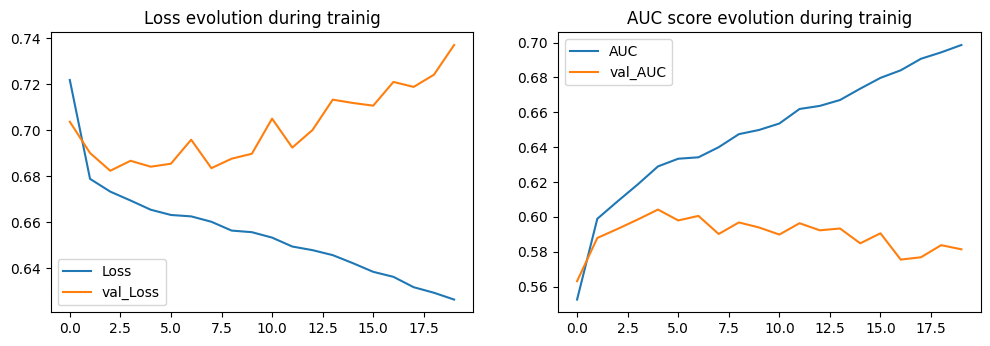

In [81]:
plot_learning_evolution(r)

In [82]:
y_train_pred = model.predict(X_train)
evaluate_nn(y_train, y_train_pred.round(), train=True)

825/825 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
Train Result:
Accuracy Score: 70.43%
_______________________________________________
CLASSIFICATION REPORT:
                    0.0           1.0  accuracy     macro avg  weighted avg
precision      0.689393      0.716400  0.704265      0.702897      0.703817
recall         0.664822      0.738677  0.704265      0.701749      0.704265
f1-score       0.676885      0.727368  0.704265      0.702126      0.703846
support    12289.000000  14086.000000  0.704265  26375.000000  26375.000000
_______________________________________________
Confusion Matrix: 
 [[ 8170  4119]
 [ 3681 10405]]



In [90]:
scores_dict = {
    'ANNs': {
        'Train': roc_auc_score(y_train, model.predict(X_train)),
        'Test': roc_auc_score(y_test, model.predict(X_test)),
    },

}

825/825 ━━━━━━━━━━━━━━━━━━━━ 1s 860us/step
279/279 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  


{'ANNs': {'Train': np.float64(0.7713459305529415),
  'Test': np.float64(0.5814361041837653)}}

## XGBOOST

In [93]:
from scipy import stats
from sklearn.model_selection import RandomizedSearchCV
from xgboost import XGBClassifier

param_grid = dict(
    n_estimators=stats.randint(10, 500),
    max_depth=stats.randint(1, 10),
    learning_rate=stats.uniform(0.01, 0.3)
)

xgb_clf = XGBClassifier(
    eval_metric='auc',
    tree_method='hist',
    random_state=168
)

xgb_cv = RandomizedSearchCV(
    xgb_clf, param_grid, cv=3, n_iter=60,
    scoring='roc_auc', n_jobs=-1, verbose=1, random_state=168
)
xgb_cv.fit(X_train, y_train)

best_params = xgb_cv.best_params_
best_params.update({
    'tree_method': 'hist',
    'eval_metric': 'auc',
    'random_state': 168
})
print(f"Best Parameters: {best_params}")

xgb_clf = XGBClassifier(**best_params)
xgb_clf.fit(X_train, y_train)

y_train_pred = xgb_clf.predict(X_train)
y_test_pred = xgb_clf.predict(X_test)

print_score(y_train, y_train_pred, train=True)
print_score(y_test, y_test_pred, train=False)

Fitting 3 folds for each of 60 candidates, totalling 180 fits
Best Parameters: {'learning_rate': np.float64(0.12440806278190071), 'max_depth': 2, 'n_estimators': 305, 'tree_method': 'hist', 'eval_metric': 'auc', 'random_state': 168}
Train Result:
Accuracy Score: 61.52%
_______________________________________________
CLASSIFICATION REPORT:
                    0.0           1.0  accuracy     macro avg  weighted avg
precision      0.603902      0.622511  0.615242      0.613206      0.613840
recall         0.506306      0.710280  0.615242      0.608293      0.615242
f1-score       0.550814      0.663506  0.615242      0.607160      0.610999
support    12289.000000  14086.000000  0.615242  26375.000000  26375.000000
_______________________________________________
Confusion Matrix: 
 [[ 6222  6067]
 [ 4081 10005]]

Test Result:
Accuracy Score: 59.33%
_______________________________________________
CLASSIFICATION REPORT:
                   0.0          1.0  accuracy    macro avg  weighted avg

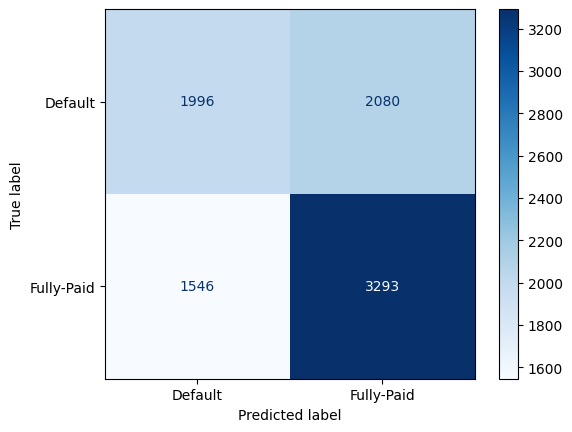

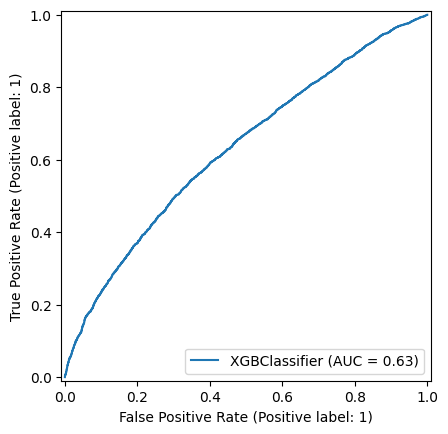

In [94]:
from sklearn.metrics import ConfusionMatrixDisplay, RocCurveDisplay

disp = ConfusionMatrixDisplay.from_estimator(
    xgb_clf, X_test, y_test, 
    cmap='Blues', values_format='d', 
    display_labels=['Default', 'Fully-Paid']
)

disp = RocCurveDisplay.from_estimator(xgb_clf, X_test, y_test)

In [95]:
scores_dict['XGBoost'] = {
        'Train': roc_auc_score(y_train, xgb_clf.predict(X_train)),
        'Test': roc_auc_score(y_test, xgb_clf.predict(X_test)),
    }


{'ANNs': {'Train': np.float64(0.7713459305529415),
  'Test': np.float64(0.5814361041837653)},
 'XGBoost': {'Train': np.float64(0.6082930816380416),
  'Test': np.float64(0.5851041413799111)}}

In [98]:
ml_models = {
    'XGBoost': xgb_clf, 
    'ANNs': model
}

for model in ml_models:
    print(f"{model.upper():{30}} roc_auc_score: {roc_auc_score(y_test, ml_models[model].predict(X_test)):.3f}")

XGBOOST                        roc_auc_score: 0.585
279/279 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  
ANNS                           roc_auc_score: 0.581


In [99]:

scores_df = pd.DataFrame(scores_dict)
scores_df.hvplot.barh(
    width=500, height=400, 
    title="ROC Scores of ML Models", xlabel="ROC Scores", 
    alpha=0.4, legend='top'
)

:Bars   [index,Variable]   (value)